In [ ]:
!uv pip install numpy matplotlib torch transformers scikit-learn peft
# OR pip install -r requirements.txt


Using Python 3.12.12 environment at: /Users/cretuluca/uni/ro-doc-classification/.venv
Audited 6 packages in 42ms


In [1]:
import sys
sys.path.insert(0, "/Users/cretuluca/uni/ro-doc-classification")

from src.utils.config import load_config, get_device
from src.data.dataset import load_data
from src.training.lora import load_model, train
from src.eval.metrics import count_parameters, evaluate, measure_latency, save_results

config = load_config()
device = get_device()

/Users/cretuluca/uni/ro-doc-classification/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
splits, tokenizer = load_data(config)

Loaded 21719 training samples...
Loaded 5921 validation samples...
Loaded 5924 test samples...


In [3]:
model = load_model(config)
trainable_params, total_params = count_parameters(model)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 60264.73it/s]
BertForSequenceClassification LOAD REPORT from: readerbench/RoBERT-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ign

Trainable parameters: 299,526 | Total: 115,366,668 | Percentage: 0.26%


In [4]:
trainer = train(model, splits["train"]["dataset"], splits["validation"]["dataset"], config)

/Users/cretuluca/uni/ro-doc-classification/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy
1,0.620980,0.426011,0.833981
2,0.419434,0.400138,0.849012
3,0.384846,0.379476,0.851545
4,0.360679,0.368445,0.859145
5,0.346775,0.365433,0.859314


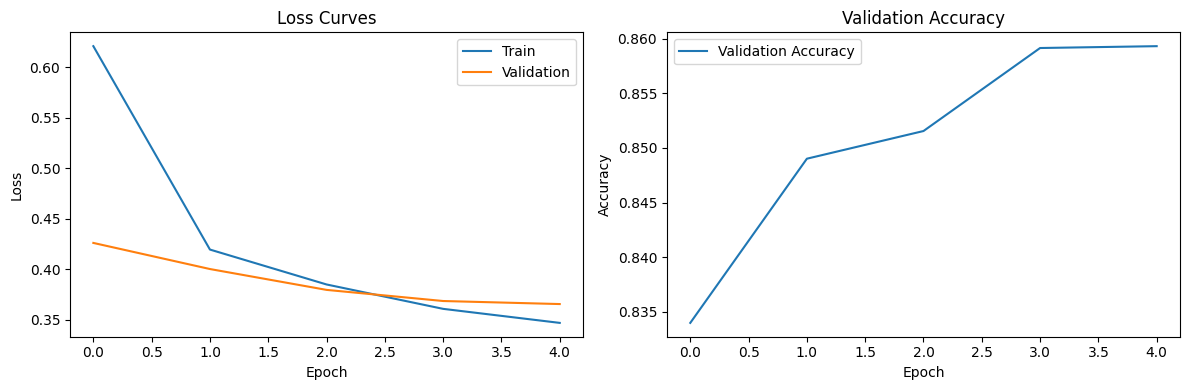

In [5]:
import matplotlib.pyplot as plt

log = trainer.state.log_history
train_loss = [e["loss"] for e in log if "loss" in e and "eval_loss" not in e]
val_loss = [e["eval_loss"] for e in log if "eval_loss" in e]
val_acc = [e["eval_accuracy"] for e in log if "eval_accuracy" in e]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_loss, label="Train")
ax1.plot(val_loss, label="Validation")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss Curves")
ax1.legend()

ax2.plot(val_acc, label="Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Validation Accuracy")
ax2.legend()

plt.tight_layout()
plt.savefig("outputs/lora/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
_, _, report_dict, cm = evaluate(trainer.model, splits["test"]["dataset"], device, config["training"]["lora"]["batch_size"])

              precision    recall  f1-score   support

         CUL       0.82      0.88      0.85       404
         FIN       0.81      0.82      0.81      1506
         POL       0.86      0.82      0.84      1612
         SCI       0.88      0.87      0.87       515
         SPO       0.99      0.98      0.98      1064
         TEC       0.81      0.83      0.82       823

    accuracy                           0.86      5924
   macro avg       0.86      0.87      0.86      5924
weighted avg       0.86      0.86      0.86      5924

Confusion matrix:
[[ 357    8   18    6    3   12]
 [  27 1237  165    7    3   67]
 [  34  214 1327    6    4   27]
 [   5    8    3  449    1   49]
 [   4    5    9    2 1038    6]
 [   7   63   24   42    2  685]]


In [7]:
max_len = config["model"]["max_length"]
sample_text = splits["test"]["samples"][0]
latency_ms = measure_latency(trainer.model, tokenizer, sample_text, device, max_len)

Average Inference Latency: 28.03 ms per document (50 iterations)


In [8]:
save_results("outputs/lora", config, trainer, report_dict, cm, latency_ms, trainable_params, total_params)

Results saved to outputs/lora/
Model saved to models/lora/
